<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Patch - Solar Orbiter
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [2]:
""" Import Modules """
import numpy             as np
import pandas            as pd
import speasy            as spz
import matplotlib.pyplot as plt

from pathlib           import Path
from matplotlib        import rcParams
from scipy.interpolate import interp1d
from scipy             import interpolate, stats
from datetime          import datetime, timedelta

from f_patch import average, load_data_solo, _read_velocirap_file, resample_dataframe

In [3]:
""" Plot Config """
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 18
rcParams['axes.labelsize'] = 15
rcParams['xtick.labelsize'] = 13
rcParams['ytick.labelsize'] = 13
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 18

rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['grid.linestyle'] = '--'
rcParams['grid.linewidth'] = 0.5

In [122]:
""" Time Config """
start_SOLO = datetime(2025, 3, 17) 
stop_SOLO  = datetime(2025, 4, 13)

In [124]:
""" Get Data """ 
data_solo = load_data_solo(start_SOLO, stop_SOLO)
data_solo

,car_lon,car_lat,r_sun,Np,Vp_r,Vp_t,Vp_n,Tp,Br,Bt,Bn
2025-03-17 00:00:00.176999936,176.418162,-15.283978,0.423160,3.643799,379.363373,94.679123,-41.890675,33.653782,-34.235580,15.949701,1.559939
2025-03-17 00:00:01.176999936,176.418041,-15.283984,0.423160,3.947945,376.990051,101.582245,-38.163555,32.619854,-33.965054,16.377220,1.759863
2025-03-17 00:00:02.176999936,176.417921,-15.283989,0.423160,3.706120,383.627808,101.958160,-43.232319,34.343788,-33.729202,16.882778,0.961502
2025-03-17 00:00:03.176999936,176.417800,-15.283994,0.423160,3.876642,375.535400,108.722351,-42.814110,36.546280,-33.706581,16.975887,1.033507
2025-03-17 00:00:04.176999936,176.417680,-15.284000,0.423160,4.515287,366.548828,106.747696,-52.864479,35.308254,-33.808865,16.623711,0.720834
...,...,...,...,...,...,...,...,...,...,...,...
2025-04-12 23:59:52.604000000,-46.248035,12.034859,0.395143,95.295967,433.878418,-16.478552,-0.780262,35.340309,-40.739613,21.427841,-0.186582
2025-04-12 23:59:53.604000000,-46.248150,12.034869,0.395143,95.227074,434.101776,-16.725679,-1.237523,36.176323,-41.478874,19.683432,-0.562432
2025-04-12 23:59:54.604000000,-46.248266,12.034879,0.395143,91.542542,430.164062,-21.756344,-4.196255,35.871956,-43.493576,16.097651,-0.652600
2025-04-12 23:59:55.604000000,-46.248381,12.034889,0.395143,93.915497,429.115967,-25.754433,-3.405156,35.617874,-42.903080,16.128126,-1.086294


In [125]:
""" Derived Parameters """
# alpha_abundance_solo = data_solo['Na'] / (data_solo['Na'] + data_solo['Np'])*100

' Derived Parameters '

Text(1.08, 0.5, '— $r$ $[AU]$')

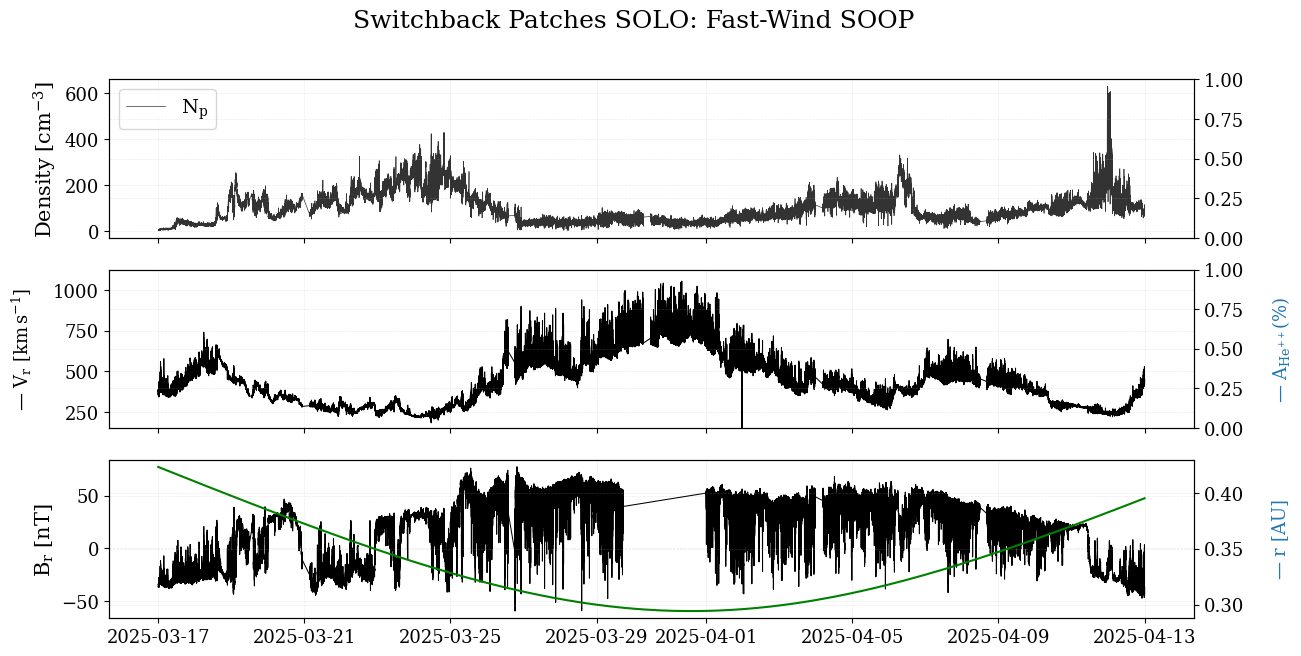

In [126]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14,7))
fig.suptitle("Switchback Patches SOLO: Fast-Wind SOOP")

plt.rcParams["mathtext.default"] = "regular"

time_index = data_solo.index

ax1b = ax1.twinx()
ax1.plot(time_index, data_solo['Np'], label='$N_p$', color='black', linewidth='0.5', alpha=0.8)
# ax1b.plot(Na_PSP.index, Na_PSP.iloc[:,0], label='$N_a$', color='tab:red', linewidth='0.5', alpha=0.8)
ax1.legend(loc='upper left')
# ax1b.legend(loc='upper right')
ax1.set_ylabel('Density $[cm^{-3}]$')

ax2b = ax2.twinx()
ax2.plot(time_index, data_solo['Vp_r'], label='$V_p$', color='black', linewidth='0.75')
# ax2b.plot(time_index,alpha_abundance_PSP_average,label=r'$\alpha _{\%}$',color='tab:blue',linewidth=0.75,alpha=0.8)
# ax2b.set_yscale('log')
ax2.annotate(
    r'— $V_r$ $[km\,s^{-1}]$',
    xy=(-0.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='black')
ax2.set_ylim(150, None)

ax2b.annotate(
    r'— $A_{He^{++}} (\%)$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')

ax3b = ax3.twinx()
ax3.plot(time_index, data_solo['Br'], color ='black', linewidth='0.75')
ax3b.plot(time_index, data_solo['r_sun'], color='green')
ax3.set_ylabel('$B_r$ $[nT]$')
ax3b.annotate(
    r'— $r$ $[AU]$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')
# ax3b.set_ylim(None,0.2)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Angular Displacement
</p>

</div>

In [128]:
""" Ephemeris Data """
phi, theta, solo_r_sun = data_solo['car_lon'], data_solo['car_lat'], data_solo['r_sun']

In [129]:
phi

2025-03-17 00:00:00.176999936    176.418162
2025-03-17 00:00:01.176999936    176.418041
2025-03-17 00:00:02.176999936    176.417921
2025-03-17 00:00:03.176999936    176.417800
2025-03-17 00:00:04.176999936    176.417680
                                    ...    
2025-04-12 23:59:52.604000000    -46.248035
2025-04-12 23:59:53.604000000    -46.248150
2025-04-12 23:59:54.604000000    -46.248266
2025-04-12 23:59:55.604000000    -46.248381
2025-04-12 23:59:56.604000000    -46.248497
Name: car_lon, Length: 2081802, dtype: float64

In [131]:
t_coord = time_index

phi_rad   = phi * np.pi/180
theta_rad = theta * np.pi/180

phi_rad_new   = phi_rad#['lon iau_sun']
theta_rad_new = theta_rad#['lat iau_sun']

t_coord_float = t_coord.astype(np.int64) / 1e9
df_time_float = data_solo['Vp_r'].index.astype(np.int64) / 1e9

interp_theta = interp1d(t_coord_float, theta_rad_new, kind='linear', bounds_error=False, fill_value="extrapolate")
interp_phi   = interp1d(t_coord_float, phi_rad_new,   kind='linear', bounds_error=False, fill_value="extrapolate")

theta_z = interp_theta(df_time_float)
phi_z   = interp_phi(df_time_float)

dtheta = np.diff(theta_z)
dphi   = np.diff(phi_z)

ds_solo    = np.sqrt(dtheta**2 + (np.cos(theta_z[:-1]) * dphi)**2)
s_solo     = np.concatenate([[0], np.cumsum(ds_solo)])
s_solo_deg = np.degrees(s_solo)

(150.0, 1126.7762237548827)

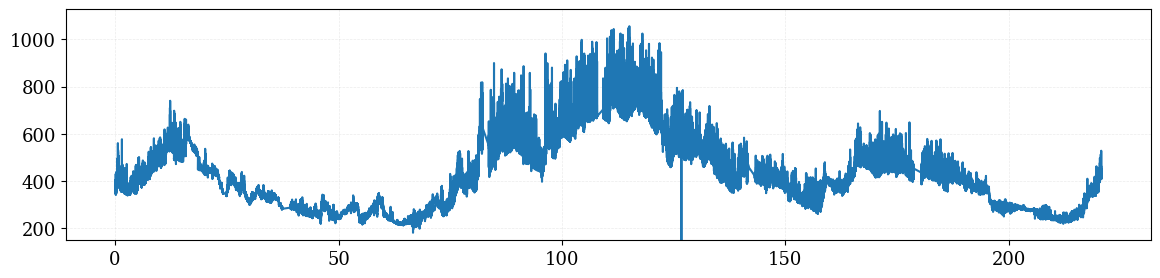

In [132]:
plt.figure(figsize=(14,3))
plt.plot(s_solo_deg, data_solo['Vp_r'])
plt.ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Fourier Analysis
</p>

</div>

In [134]:
f_cut = 9.3e-2

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Normalised Deflection

In [136]:
""" Compute Normalised Deflection """

' Compute Normalised Deflection '

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Velocity

In [140]:
data_solo['Vp_r'] = data_solo['Vp_r'].fillna(data_solo['Vp_r'].mean())

# --- Regular sampling ---
s_solo_new = np.linspace(0, max(s_solo_deg), int(max(s_solo_deg)/min(np.diff(s_solo_deg))))

v_r_interp = interp1d(s_solo_deg, data_solo['Vp_r'], kind='linear', bounds_error=False, fill_value="extrapolate")
v_r_new = v_r_interp(s_solo_new)

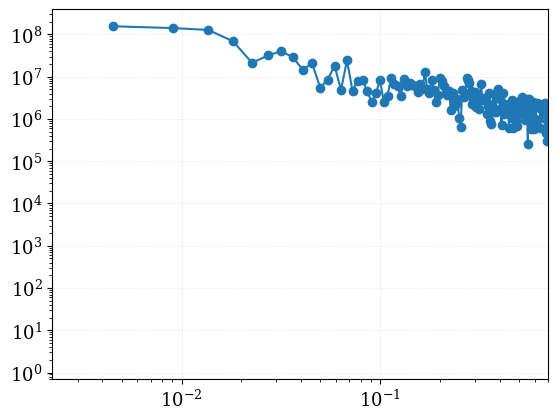

In [141]:
# --- velocity
ds_vr = np.mean(np.diff(s_solo_new))

fft_vr  = np.fft.rfft(v_r_new)
freq_vr = np.fft.rfftfreq(len(v_r_new), d=ds_vr)

plt.loglog(freq_vr[1:], np.abs(fft_vr[1:]))
plt.scatter(freq_vr[1:], np.abs(fft_vr[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 7e-1)
plt.show()

In [142]:
idx_cut_vr = np.argmin(np.abs(freq_vr - f_cut))

fft_vr[idx_cut_vr:] = 0.0

(150.0, 1119.3097914534123)

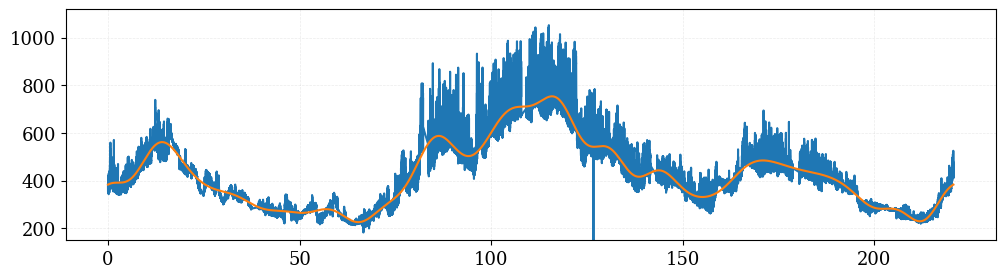

In [154]:
filter_data_vr = np.fft.irfft(fft_vr)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_solo_new, v_r_new)
ax.plot(s_solo_new[:-1], filter_data_vr)
ax.set_ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Alpha Abundance

In [156]:
velocirap = False

if velocirap:
    data = _read_velocirap_file(start_SOLO, stop_SOLO)
    data_res = resample_dataframe(data, data_solo.index)

else:
    l3_path = spz.inventories.data_tree.amda.DerivedParameters
    Na = spz.get_data(l3_path.pas_na_nomag, start_SOLO, stop_SOLO).to_dataframe()
    Np = spz.get_data(l3_path.pas_np_nomag, start_SOLO, stop_SOLO).to_dataframe()
    data = pd.concat([Np, Na],axis=1)
    data_res = resample_dataframe(data, data_solo.index)
    
data_res

,PAS Proton Density,PAS alpha density
2025-03-17 00:00:00.176999936,NaN,NaN
2025-03-17 00:00:01.176999936,NaN,NaN
2025-03-17 00:00:02.176999936,NaN,NaN
2025-03-17 00:00:03.176999936,NaN,NaN
2025-03-17 00:00:04.176999936,NaN,NaN
...,...,...
2025-04-12 23:59:52.604000000,70.519669,6.288678
2025-04-12 23:59:53.604000000,70.519669,6.288678
2025-04-12 23:59:54.604000000,70.519669,6.288678
2025-04-12 23:59:55.604000000,70.519669,6.288678


In [157]:
if velocirap:
    alpha_abundance_SOLO = (data_res['Na'] / (data_res['Na'] + data_res['Np'])) * 100
    alpha_percent = pd.DataFrame(alpha_abundance_SOLO)
    alpha_percent.columns = ["a_percent"]   
else:
    alpha_abundance_SOLO = (data_res['PAS alpha density'] / (data_res['PAS alpha density'] + data_res['PAS Proton Density'])) * 100
    alpha_percent = pd.DataFrame(alpha_abundance_SOLO)
    alpha_percent.columns = ["a_percent"]   

In [158]:
alpha_percent.loc[np.isnan(alpha_percent['a_percent']), "a_percent"] = np.mean(alpha_percent['a_percent'])

# --- Regular sampling ---
a_percent_interp = interp1d(s_solo_deg, alpha_percent['a_percent'], kind='linear', bounds_error=False, fill_value="extrapolate")
a_percent_new = a_percent_interp(s_solo_new)

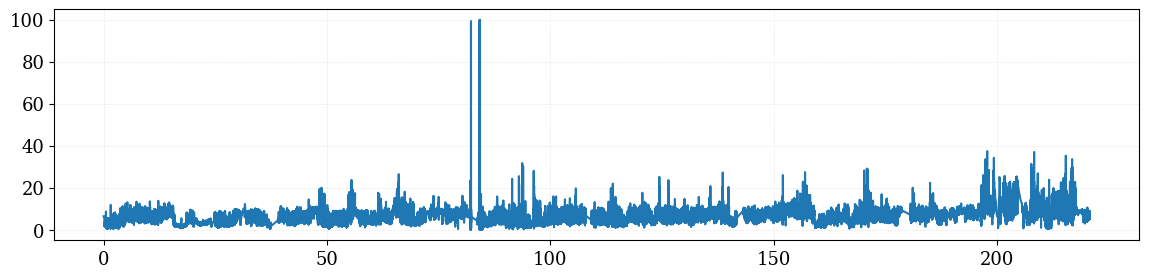

In [159]:
plt.figure(figsize=(14, 3))
plt.plot(s_solo_new, a_percent_new)

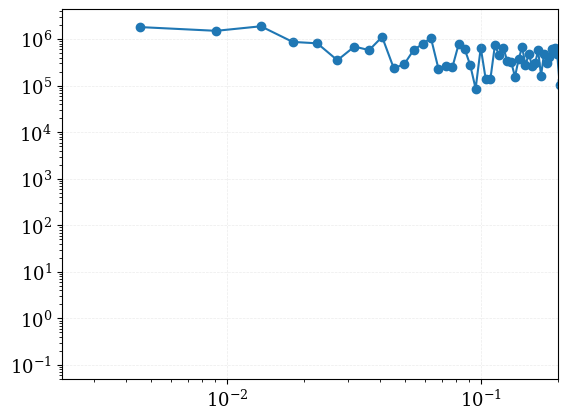

In [160]:
# --- alpha abundance
ds_a_percent = np.mean(np.diff(s_solo_new))

fft_a_percent  = np.fft.rfft(a_percent_new)
freq_a_percent = np.fft.rfftfreq(len(a_percent_new), d=ds_a_percent)

plt.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
plt.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 2e-1)
plt.show()

In [161]:
idx_cut_a_percent = np.argmin(np.abs(freq_a_percent - f_cut))

fft_a_percent[idx_cut_a_percent:] = 0.0

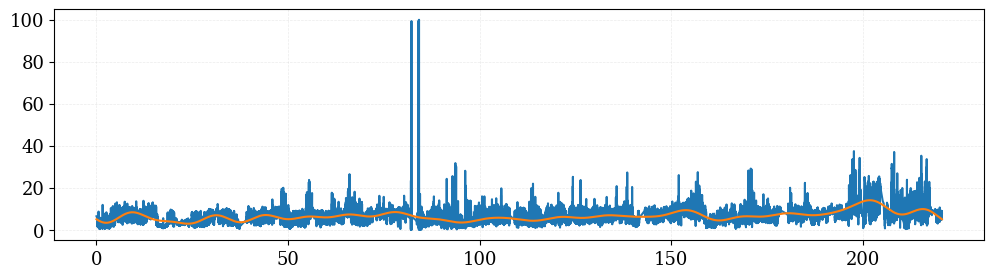

In [164]:
filter_data_a_percent = np.fft.irfft(fft_a_percent)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_solo_new, a_percent_new)
ax.plot(s_solo_new[:-1], filter_data_a_percent)
#ax.set_ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Correlation
</p>

</div>

In [166]:
r_a_vr, p_a_vr = stats.pearsonr(filter_data_vr, filter_data_a_percent)
r_a_vr

np.float64(-0.404198634140735)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Figures
</p>

</div>

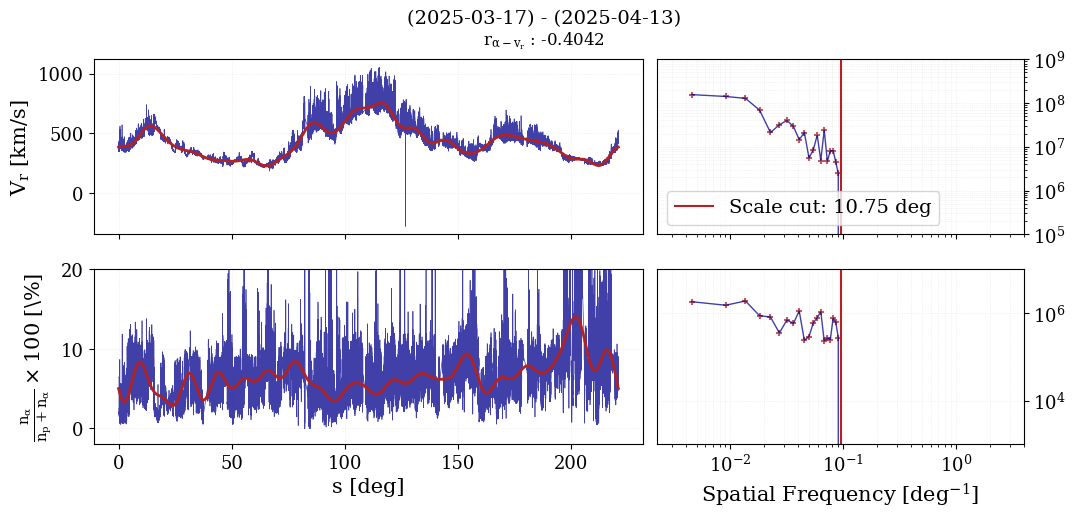

In [180]:
fig = plt.figure(figsize=(12, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1], wspace=0.03, hspace=0.2)

fig.suptitle(
    rf"({start_SOLO.strftime('%Y-%m-%d')}) - ({stop_SOLO.strftime('%Y-%m-%d')})",
    fontsize=14
)

fig.text(
    0.5, 0.94,
    rf"$r_{{\alpha-v_r}}$ : {r_a_vr:.4f}",
    ha="center",
    va="top",
    fontsize=12
)

# Left column: time series
ax_v = fig.add_subplot(gs[0, 0])
ax_a = fig.add_subplot(gs[1, 0], sharex=ax_v)

# Right column: spectra
ax_v_spec = fig.add_subplot(gs[0, 1])
ax_a_spec = fig.add_subplot(gs[1, 1])#, sharex=ax_v_spec)

# Velocity time series
ax_v.plot(s_solo_new, v_r_new, color = 'darkblue', linewidth=0.5, alpha=0.75)
ax_v.plot(s_solo_new[:-1], filter_data_vr, linewidth=2.0, color='firebrick')
ax_v.set_ylabel(r"$V_r$ [$km/s$]")
ax_v.tick_params(labelbottom=False)
ax_v.grid(which="both", linestyle=":", alpha=0.3)

# Velocity spectrum
ax_v_spec.loglog(freq_vr[1:], np.abs(fft_vr[1:]), linewidth=1, color='darkblue', alpha=0.75)
ax_v_spec.scatter(freq_vr[1:], np.abs(fft_vr[1:]), marker="+", color="firebrick", s=20, alpha=0.75)
ax_v_spec.axvline(freq_vr[idx_cut_vr], color="firebrick", linestyle="-", linewidth=1.5, label=f"Scale cut: {round(1/f_cut, 2)} deg")
ax_v_spec.set_xlim(None, 4e0)
ax_v_spec.set_ylim(1e5, 1e9)
ax_v_spec.grid(which="both", linestyle=":", alpha=0.3)
ax_v_spec.tick_params(labelbottom=False)
ax_v_spec.legend(loc="lower left")

# Alpha abundance time series
ax_a.plot(s_solo_new, a_percent_new, linewidth=0.5, color='darkblue', alpha=0.75)
ax_a.plot(s_solo_new[:-1], filter_data_a_percent, color="firebrick", linewidth=2.0)
ax_a.set_ylabel(r"$\frac{n_\alpha}{n_p+n_\alpha}\times100$ [\%]")
ax_a.set_xlabel("s [deg]")
ax_a.set_ylim(-2, 20)
ax_a.grid(which="both", linestyle=":", alpha=0.3)

# Alpha spectrum
ax_a_spec.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]), linewidth=1, color='darkblue', alpha=0.75)
ax_a_spec.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]), marker="+", color="firebrick", s=20, alpha=0.75)
ax_a_spec.axvline(freq_a_percent[idx_cut_a_percent], color="firebrick", linestyle="-", linewidth=1.5)
ax_a_spec.set_xlabel("Spatial Frequency [$deg^{-1}$]")
ax_a_spec.set_xlim(None, 4e0)
ax_a_spec.set_ylim(1e3, 1e7)
ax_a_spec.grid( which="both", linestyle=":", alpha=0.3)

ax_v_spec.yaxis.tick_right()
ax_v_spec.yaxis.set_label_position("right")

ax_a_spec.yaxis.tick_right()
ax_a_spec.yaxis.set_label_position("right")

# Save
#fig.savefig(
#    Path("..") / "Results" / "Figures" /
#    f"SOLO-corr_{start_SOLO.strftime('%Y-%m-%d')}_"
#    f"{stop_SOLO.strftime('%Y-%m-%d')}_"
#    f"{round(1/f_cut, 2)}.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()